In [1]:
import os
import sys
import torch
import json
import plotly.express as px
from transformer_lens import utils
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
cwd = cwd.split("notebooks")[0]
print(cwd)
sys.path.append(cwd + "/scripts")
from error_eval import *
from plots import *

/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/


# Functions

In [2]:
length_list = list(range(1, 20, 2)) + list(range(20, 50, 4)) + list(range(51, 101, 10))
col_names_normal = [f'length_{length}_kl' for length in length_list]
col_names_l2_normal = [f'length_{length}_blocks.11.hook_resid_post_L2' for length in length_list]

def melt_by_col_names(df, col_names, id_vars = None):
    if id_vars:
        mean_df_melt = pd.melt(df, id_vars=id_vars, value_vars=col_names, ignore_index=False)
    else:
        mean_df_melt = pd.melt(df, value_vars=col_names, ignore_index=False)
    mean_df_melt["perturbation_length"] = mean_df_melt["variable"].str.split("_", expand = True)[1].astype(float)

    return mean_df_melt

# Compare Different Baselines

In [3]:
layer_list = ["naive_random_itself", "cov_random_itself", "cov_random_mixture", "real_direction_mixture", "real_direction_itself"]

mean_df_dict = {}
sample_df_dict = {}

for layer in layer_list:
    print(layer)
    filename = f"{layer}_seed_23_layer_6_pos_all.csv"
    result_df = pd.read_csv(cwd + "/results/sensitive_direction/gpt2_resid_pre/" + filename)

    mean_df = pd.DataFrame(result_df.mean(axis=0)).T
    df_sample = result_df.sample(n = 10000)

    mean_df_dict[layer] = mean_df
    sample_df_dict[layer] = df_sample

naive_random_itself
cov_random_itself
cov_random_mixture
real_direction_mixture
real_direction_itself


In [4]:
mean_df_list = []
for layer in layer_list:
    mean_df = mean_df_dict[layer]
    mean_df["type"] = layer
    mean_df_list.append(mean_df)

mean_df_all = pd.concat(mean_df_list)

In [5]:
mean_df_all_melt_l2 = melt_by_col_names(mean_df_all, col_names_l2_normal, id_vars = ["type"])
mean_df_all_melt_l2["metric"] = "L2 distance at Layer 11 resid_post"

mean_df_all_melt_kl = melt_by_col_names(mean_df_all, col_names_normal, id_vars = ["type"])
mean_df_all_melt_kl["metric"] = "KL"

mean_df_all_melt = pd.concat([mean_df_all_melt_l2, mean_df_all_melt_kl])

col_labels = {
    'naive_random_itself': 'isotropic random',
    'cov_random_itself': 'cov-random subtraction, $x^j = x^{base}$',
    'cov_random_mixture': 'cov-random subtraction, mixture',
    'real_direction_itself': 'real activation subtraction, $x^j = x^{base}$',
    'real_direction_mixture': 'real activation subtraction, mixture',
}

In [6]:
mean_df_all_melt = mean_df_all_melt.replace({"type": col_labels})

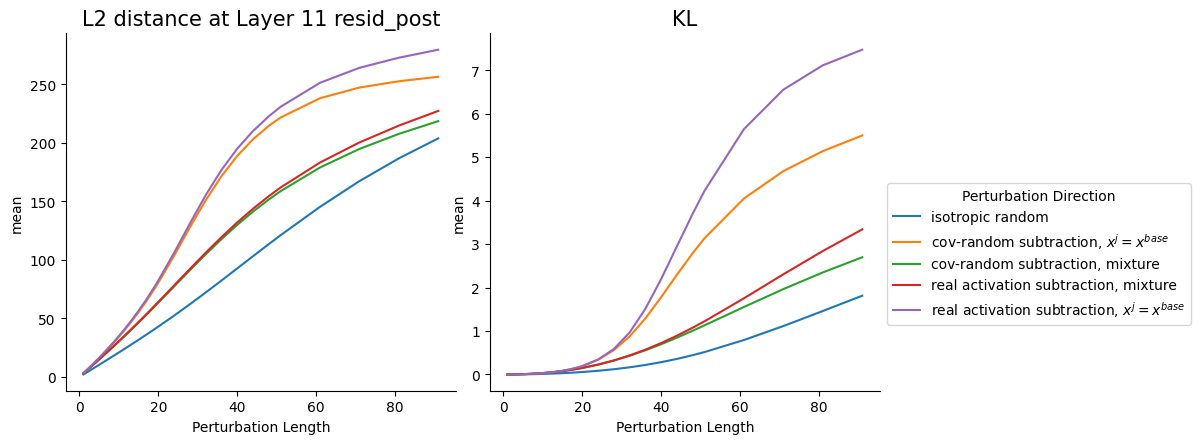

In [7]:
g = sns.FacetGrid(mean_df_all_melt, col="metric", hue = "type", sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0)

g.set(xlabel="Perturbation Length", ylabel = "mean")
g.set_titles(col_template="{col_name}", size = 15)

# g.set_title('Perturbation at Layer 6 Resid_pre from Base Activation')
plt.legend(title = "Perturbation Direction", bbox_to_anchor = [1.0, 0.6])

# plt.subplots_adjust(right=0.3)

plt.savefig(f"{cwd}/results/figures/sensitive_directions.png", dpi = 500, bbox_inches = "tight")


## plot samples

In [27]:
layer_list = ["_", "_mixture_", "_to_"]

df_all_melt_all = pd.DataFrame()

for layer in layer_list:
    print(layer)
    sample_df = sample_df_dict[layer]
    
    df_all_melt_l2 = melt_by_col_names(sample_df, col_names_l2_normal)
    df_all_melt_l2["metric"] = "L2 at Layer 11 resid_post"
    df_all_melt_kl = melt_by_col_names(sample_df, col_names_normal)
    df_all_melt_kl["metric"] = "kl"
    df_all_melt = pd.concat([df_all_melt_l2, df_all_melt_kl])
    df_all_melt["type"] = layer    
    df_all_melt_all = pd.concat([df_all_melt_all, df_all_melt])


_
_mixture_
_to_


In [28]:
df_all_melt_all

,variable,value,perturbation_length,metric,type
1818105,length_1_blocks.11.hook_resid_post_L2,2.229242,1.0,L2 at Layer 11 resid_post,_
154977,length_1_blocks.11.hook_resid_post_L2,3.304089,1.0,L2 at Layer 11 resid_post,_
89497,length_1_blocks.11.hook_resid_post_L2,3.531239,1.0,L2 at Layer 11 resid_post,_
1361020,length_1_blocks.11.hook_resid_post_L2,2.809841,1.0,L2 at Layer 11 resid_post,_
1645165,length_1_blocks.11.hook_resid_post_L2,1.745594,1.0,L2 at Layer 11 resid_post,_
...,...,...,...,...,...
923062,length_91_kl,1.438003,91.0,kl,_to_
609780,length_91_kl,3.722593,91.0,kl,_to_
1474902,length_91_kl,4.781805,91.0,kl,_to_
735196,length_91_kl,6.075806,91.0,kl,_to_


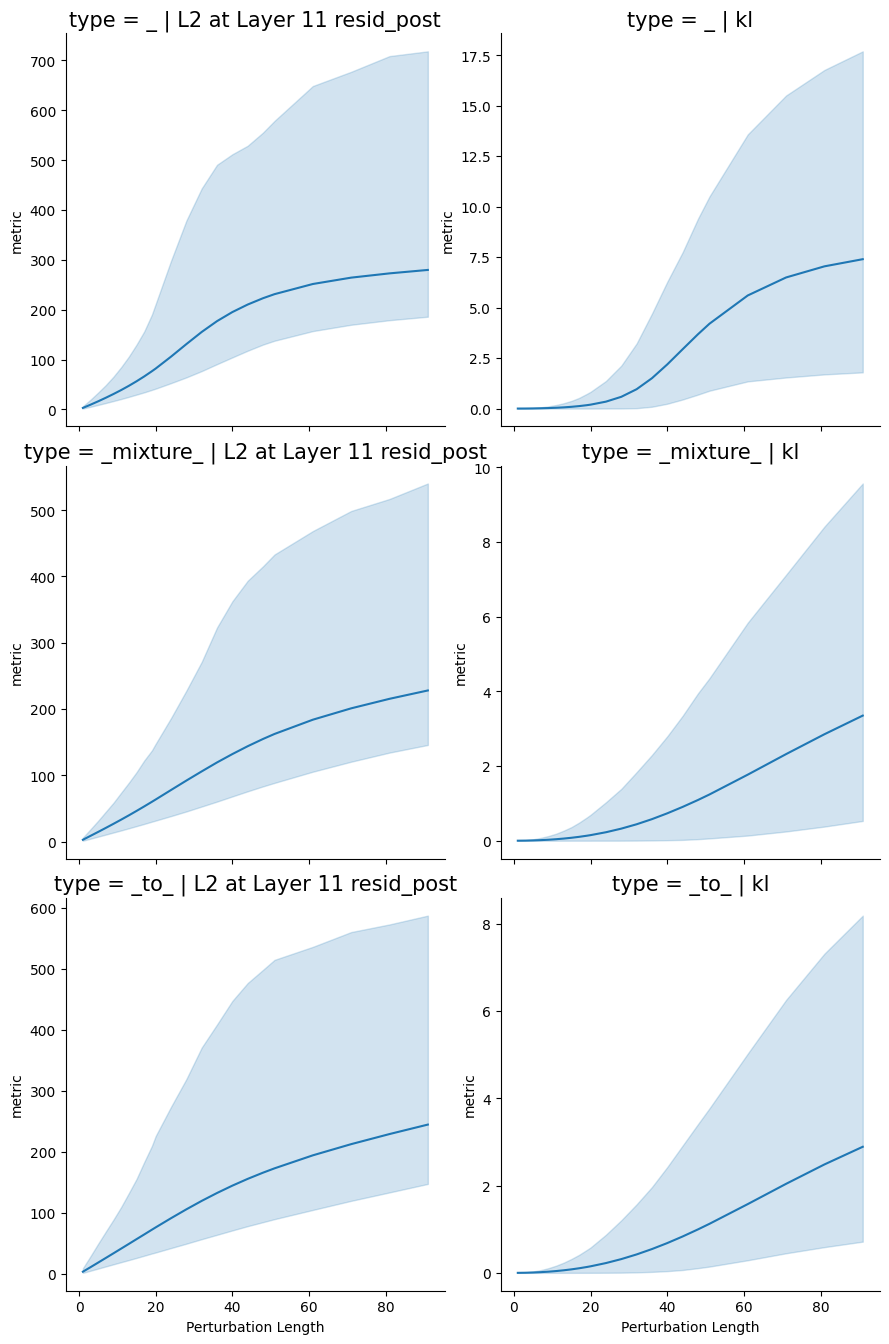

In [30]:
g = sns.FacetGrid(df_all_melt_all, col="metric", row = "type", sharey = False, height = 4.5)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', alpha = 1.0,  errorbar=('pi', 95))

g.set(xlabel="Perturbation Length", ylabel = "metric")
g.set_titles(col_template="{col_name}", size = 15)

# g.set_title('Perturbation at Layer 6 Resid_pre from Base Activation')
# plt.legend(title = "Perturbation Direction", bbox_to_anchor = [0.7, 1.0])



In [114]:
filename = "cov_random_seed_23_layer_6_pos_all.csv"
result_df_cov = pd.read_csv(cwd + "/results/sensitive_direction/gpt2_resid_pre/" + filename)

KeyboardInterrupt: 

In [8]:
mean_df_cov = pd.DataFrame(result_df_cov.mean(axis=0)).T


In [9]:
mean_df_cov

,token,position,loss,length_1_loss,length_1_kl,length_1_blocks.11.hook_resid_post_L2,length_3_loss,length_3_kl,length_3_blocks.11.hook_resid_post_L2,length_5_loss,...,length_181_loss,length_181_kl,length_181_blocks.11.hook_resid_post_L2,length_191_loss,length_191_kl,length_191_blocks.11.hook_resid_post_L2,length_201_loss,length_201_kl,length_201_blocks.11.hook_resid_post_L2,norm
0,4738.867746,63.0,3.557865,3.558271,0.000233,3.09915,3.560522,0.002195,9.473425,3.564976,...,11.006961,7.501078,301.804256,11.182482,7.678732,308.737078,11.354502,7.852858,315.92563,102.278208


In [6]:
filename = "real_direction_seed_23_layer_6_pos_all.csv"
result_df_real = pd.read_csv(cwd + "/results/sensitive_direction/gpt2_resid_pre/" + filename)

In [7]:
mean_df = pd.DataFrame(result_df.mean(axis=0)).T
mean_df_cov = pd.DataFrame(result_df_cov.mean(axis=0)).T
mean_df_real = pd.DataFrame(result_df_real.mean(axis=0)).T

mean_df["type"] = "sphere random"
mean_df_cov["type"] = "cov random"
mean_df_real["type"] = "real direction"
mean_df_all = pd.concat([mean_df, mean_df_cov, mean_df_real])

length_list = list(range(1, 20, 2)) + list(range(20, 50, 4)) + list(range(51, 211, 10))
col_names_normal = [f'length_{length}_kl' for length in length_list]


In [8]:
mean_df_all_melt = melt_by_col_names(mean_df_all, col_names_normal, id_vars = ["type"])

In [9]:
mean_df_all_melt

,type,variable,value,perturbation_length
0,sphere random,length_1_kl,0.000130,1.0
0,cov random,length_1_kl,0.000233,1.0
0,real direction,length_1_kl,0.000238,1.0
0,sphere random,length_3_kl,0.001173,3.0
0,cov random,length_3_kl,0.002195,3.0
...,...,...,...,...
0,cov random,length_191_kl,7.678732,191.0
0,real direction,length_191_kl,9.485449,191.0
0,sphere random,length_201_kl,4.358228,201.0
0,cov random,length_201_kl,7.852858,201.0


Text(0.5, 1.0, 'Perturbation at Layer 6 Resid_pre')

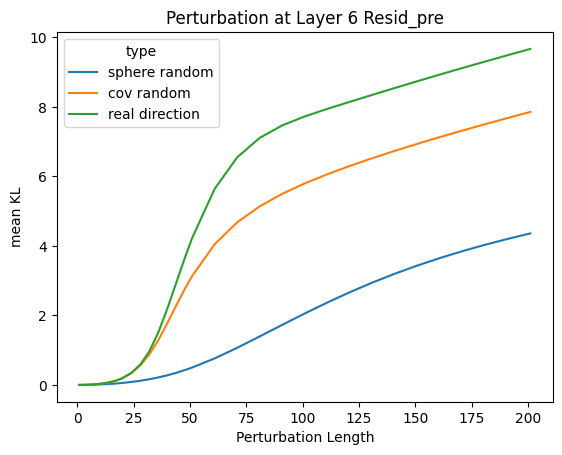

In [10]:
g = sns.lineplot(data=mean_df_all_melt, x="perturbation_length", y="value", hue = "type")
g.set(xlabel="Perturbation Length", ylabel = "mean KL")
g.set_title('Perturbation at Layer 6 Resid_pre')


Text(0.5, 1.0, 'Perturbation at Layer 6 Resid_pre')

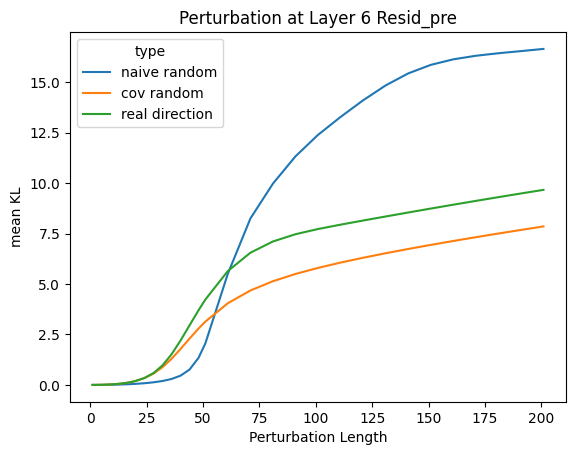

In [78]:
g = sns.lineplot(data=mean_df_all_melt, x="perturbation_length", y="value", hue = "type")
g.set(xlabel="Perturbation Length", ylabel = "mean KL")
g.set_title('Perturbation at Layer 6 Resid_pre')


In [11]:
n = 1000
result_df["type"] = "sphere random"
result_df_cov["type"] = "cov random"
result_df_real["type"] = "real direction"

df = pd.concat([result_df.sample(n = n), result_df_cov.sample(n = n), result_df_real.sample(n = n)])

In [12]:
result_df

,token,position,loss,length_1_loss,length_1_kl,length_1_blocks.11.hook_resid_post_L2,length_3_loss,length_3_kl,length_3_blocks.11.hook_resid_post_L2,length_5_loss,...,length_181_kl,length_181_blocks.11.hook_resid_post_L2,length_191_loss,length_191_kl,length_191_blocks.11.hook_resid_post_L2,length_201_loss,length_201_kl,length_201_blocks.11.hook_resid_post_L2,norm,type
0,50256,0,8.604516,8.604987,5.551655e-05,1.101497,8.606473,0.000503,3.296747,8.608714,...,2.010157,220.69144,11.642189,2.166845,235.35413,11.845028,2.318589,250.13110,3026.099900,sphere random
1,17402,1,4.787950,4.788858,9.760750e-05,1.777903,4.789594,0.000827,5.332641,4.788746,...,3.191403,256.00964,12.281322,3.238338,266.89410,12.461869,3.287006,277.46344,87.447570,sphere random
2,22038,2,3.174024,3.162852,8.667278e-05,1.458691,3.138972,0.000838,4.385334,3.113184,...,6.419005,245.10072,11.283803,6.680125,253.69576,11.600649,6.923832,262.29860,97.552980,sphere random
3,4870,3,2.832837,2.837220,2.239468e-04,2.187835,2.850033,0.001976,6.560248,2.868131,...,9.282864,403.85867,11.556744,9.422656,412.08676,11.696298,9.568531,419.91367,92.080620,sphere random
4,7806,4,0.000286,0.000277,3.538266e-07,2.555647,0.000266,0.000002,7.710899,0.000263,...,9.523746,279.47754,9.933482,9.929761,291.16818,10.292879,10.289087,302.87760,90.340290,sphere random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031995,3936,122,2.626949,2.641280,9.436218e-05,3.041989,2.673345,0.000875,9.165807,2.709907,...,1.871549,246.79936,4.423336,1.876136,255.48247,4.394996,1.889713,264.27087,89.617874,sphere random
2031996,329,123,0.903633,0.904704,6.870821e-05,1.556145,0.906888,0.000628,4.694832,0.909378,...,1.659369,267.55370,1.824557,1.697872,275.42790,1.809114,1.739577,283.02307,73.603820,sphere random
2031997,257,124,2.422075,2.424645,2.352586e-04,2.381421,2.436860,0.001943,7.097058,2.457363,...,4.117364,324.14456,8.882868,4.345060,336.34625,9.112125,4.554690,348.41187,67.952995,sphere random
2031998,1178,125,1.207364,1.206160,1.680246e-05,1.838483,1.206360,0.000158,5.438772,1.210527,...,7.160450,298.54724,9.358343,7.449671,306.20343,9.613414,7.713898,313.26862,81.346370,sphere random


In [16]:
for i in range(6):
    result_df_sample = result_df.sample(n = 4)
    result_df_cov_sample = result_df_cov.sample(n = 4)
    result_df_real_sample = result_df_real.sample(n = 4)

    df_sample = pd.concat([result_df_sample, result_df_cov_sample, result_df_real_sample])
    
    df_sample_melt = pd.melt(df_sample, id_vars = ["token", "type"], value_vars=col_names_normal, ignore_index=False)
    df_sample_melt["perturbation_length"] = df_sample_melt["variable"].str.split("_", expand = True)[1].astype(float)
    df_sample_melt["index"] = df_sample_melt.index
    df_sample_melt["iteration"] = i
    
    df_sample_melt["perturb_direction"] = df_sample_melt["type"]

    if i == 0:
        df_sample_melt_all = df_sample_melt.copy()
    else:
        df_sample_melt_all = pd.concat([df_sample_melt_all, df_sample_melt])

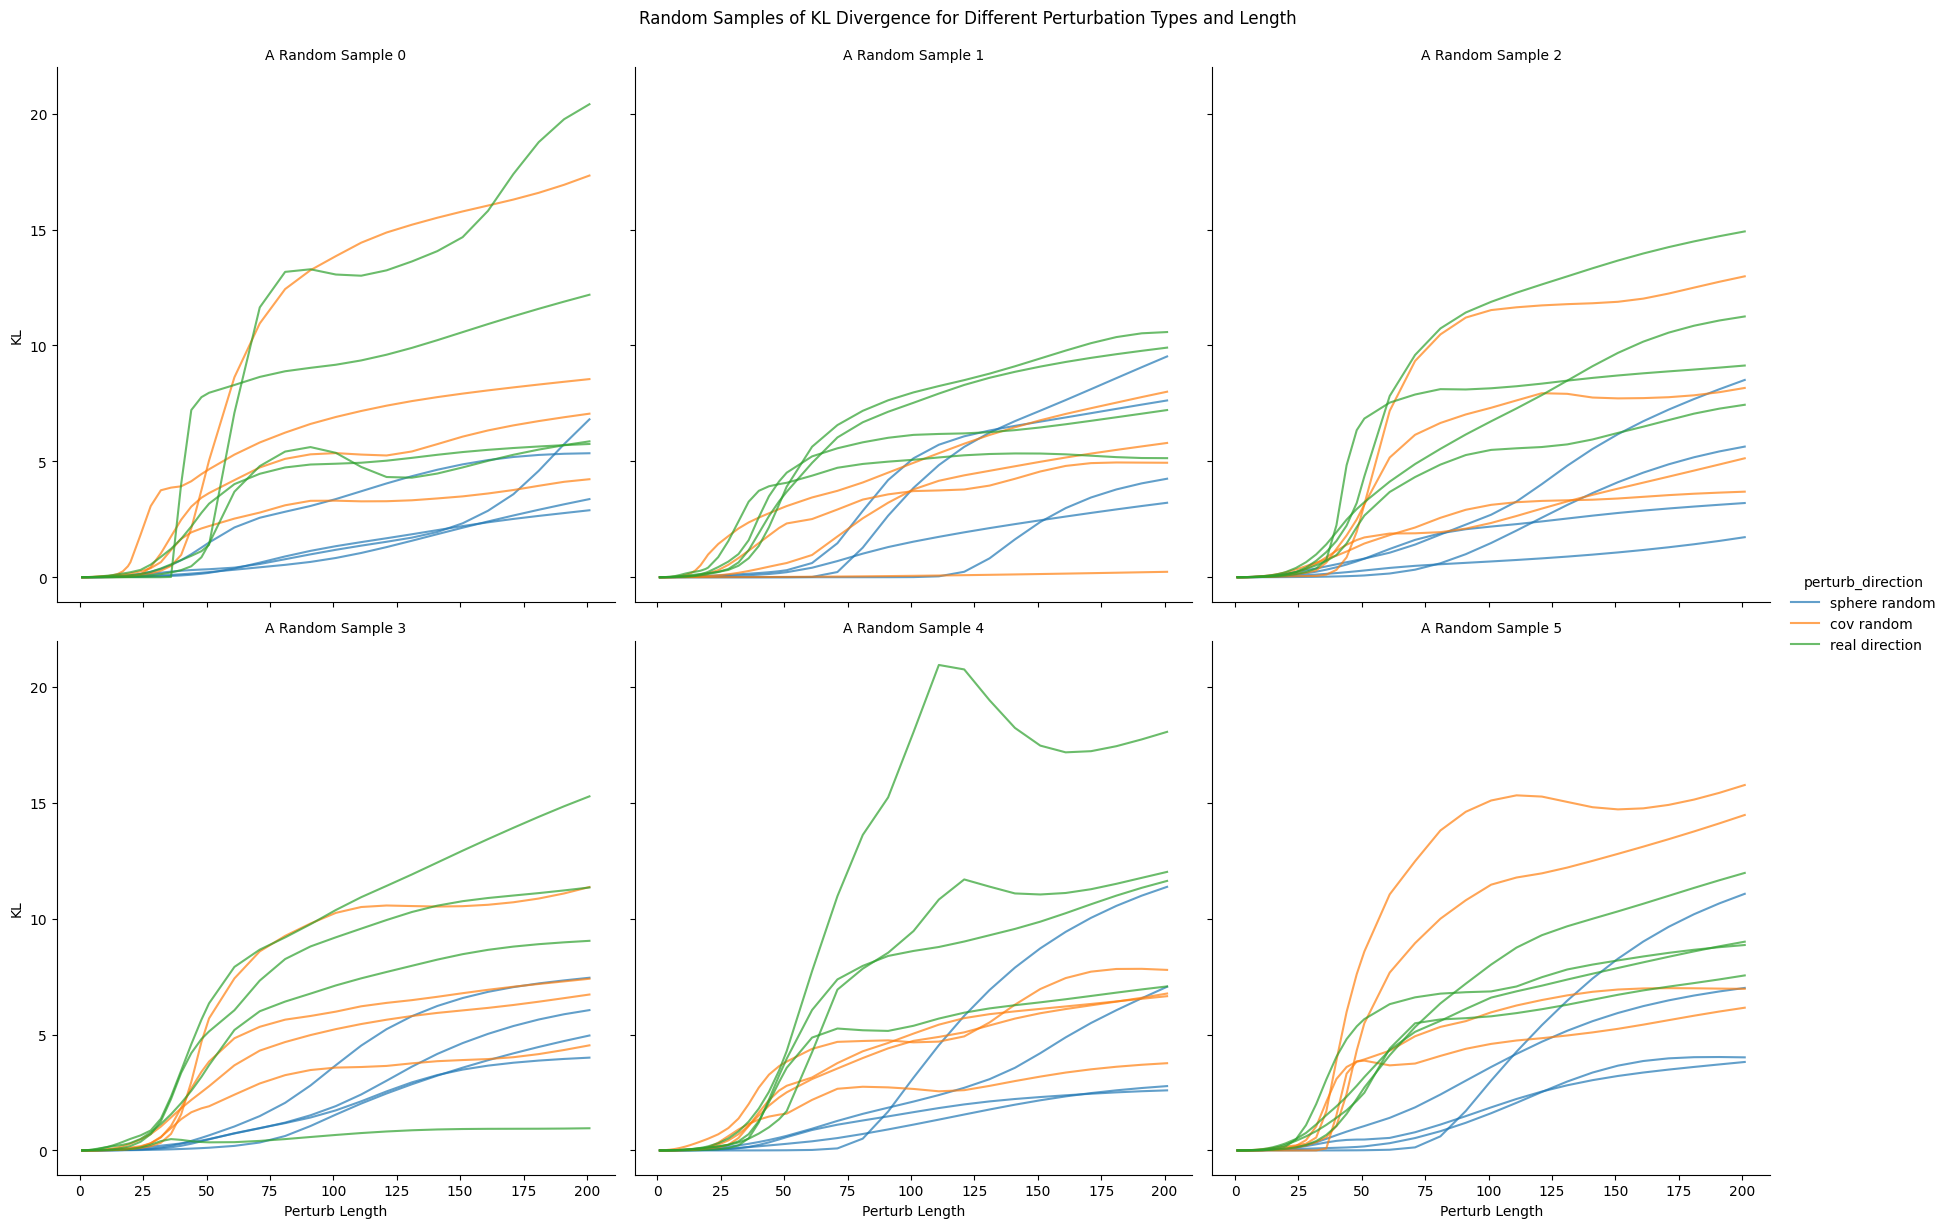

In [17]:
df_sample_melt_all_plot = df_sample_melt_all.copy()

g = sns.FacetGrid(df_sample_melt_all_plot, col="iteration", col_wrap = 3, hue = "perturb_direction", height = 6)
g.map_dataframe(sns.lineplot, x='perturbation_length', y='value', units='index', estimator=None, alpha = 0.7)
g.set_titles(col_template="A Random Sample {col_name}")

g.fig.suptitle(f'Random Samples of KL Divergence for Different Perturbation Types and Length', y = 1.02)

g.set(xlabel="Perturb Length", ylabel = "KL")
g.add_legend()

# plt.savefig("extrapolation_error.svg", format="svg", bbox_inches="tight")

Text(0.5, 1.0, 'Perturbation at Layer 6 Resid_pre')

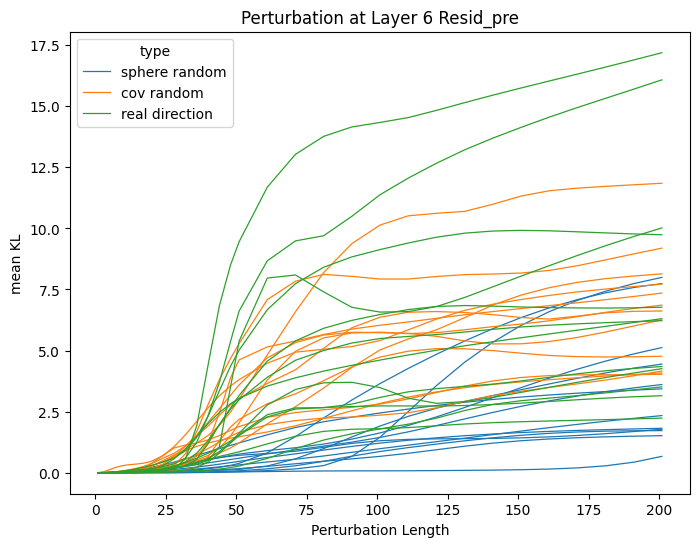

In [43]:
n = 12

result_df_sample = result_df.sample(n = 12)
result_df_cov_sample = result_df_cov.sample(n = 12)
result_df_real_sample = result_df_real.sample(n = 12)

df_sample = pd.concat([result_df_sample, result_df_cov_sample, result_df_real_sample])

df_sample_melt = pd.melt(df_sample, id_vars = ["token", "type"], value_vars=col_names_normal, ignore_index=False)
df_sample_melt["perturbation_length"] = df_sample_melt["variable"].str.split("_", expand = True)[1].astype(float)
df_sample_melt["index"] = df_sample_melt.index
df_sample_melt["iteration"] = i

df_sample_melt["perturb_direction"] = df_sample_melt["type"]

plt.subplots(figsize=(8, 6))
g = sns.lineplot(data=df_sample_melt, x="perturbation_length", y="value", hue = "type", units = "index", estimator = None, 
                 linewidth = 0.9)
g.set(xlabel="Perturbation Length", ylabel = "mean KL")
g.set_title('Perturbation at Layer 6 Resid_pre')




In [21]:
df_sample_melt

,token,type,variable,value,perturbation_length,index,iteration,perturb_direction
98763,36718,sphere random,length_1_kl,0.000184,1.0,98763,5,sphere random
1389918,983,sphere random,length_1_kl,0.000161,1.0,1389918,5,sphere random
411983,1201,sphere random,length_1_kl,0.000312,1.0,411983,5,sphere random
431870,428,sphere random,length_1_kl,0.000113,1.0,431870,5,sphere random
1006393,691,sphere random,length_1_kl,0.000081,1.0,1006393,5,sphere random
...,...,...,...,...,...,...,...,...
1166331,11,real direction,length_201_kl,8.171787,201.0,1166331,5,real direction
797335,31397,real direction,length_201_kl,9.488661,201.0,797335,5,real direction
2001875,9298,real direction,length_201_kl,11.119699,201.0,2001875,5,real direction
491781,52,real direction,length_201_kl,15.391981,201.0,491781,5,real direction
